# Laboratorio 3. Analisis exploratorio del dataset ASL Alphabet

Fabian Prado Dluzniewski 23427

Abby Donis 22440

Hansel Lopez 19026

Este notebook cubre los ejercicios 1 y 2. El objetivo es entender el dataset
antes de modelar, sabiendo que la meta final es reconocer la letra del alfabeto
ASL que aparece en una fotografia de una mano.

Las preguntas que guian el analisis son las siguientes:

1. Que resolucion y formato tienen las imagenes y son homogeneos.
2. Esta balanceado el dataset entre las 29 clases.
3. Cuanta variabilidad hay dentro de una misma letra.
4. Que letras se parecen visualmente entre si y podrian confundir al modelo.
5. Son independientes las imagenes de una misma clase o hay redundancia.
6. Como conviene construir los conjuntos de entrenamiento, validacion y prueba.

### IMPORTS

In [1]:
import logging
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

import kagglehub
from kagglesdk import KaggleClient
from kagglesdk.datasets.types.dataset_api_service import ApiListTreeDatasetFilesRequest

logging.getLogger("kagglehub").setLevel(logging.CRITICAL)
plt.style.use("seaborn-v0_8-whitegrid")

### CONFIGURACION

In [2]:
DATASET = "grassknoted/asl-alphabet"
SUB_TRAIN = "asl_alphabet_train/asl_alphabet_train"

CLASES = [chr(c) for c in range(ord("A"), ord("Z") + 1)] + ["space", "del", "nothing"]
SUBMUESTRA = 600
SEMILLA = 42

DIR_DATOS = Path("./data")
DIR_DATOS.mkdir(exist_ok=True)
RUTA_INVENTARIO = DIR_DATOS / "inventario_clases.csv"

random.seed(SEMILLA)
np.random.seed(SEMILLA)

print(f"clases {len(CLASES)}  submuestra por clase {SUBMUESTRA}")

clases 29  submuestra por clase 600


### ACCESO A LOS DATOS

El dataset pesa cerca de 1 GB y no se versiona. Se accede con la API de Kaggle
a traves de la libreria `kagglehub`, que deja todo en `~/.cache/kagglehub`,
fuera del repositorio.

Vale la pena aclarar un punto que costo trabajo durante el desarrollo.
`dataset_download` acepta un argumento `path` para traer un archivo suelto, y
esa parecia la via para bajar solo la submuestra. En la practica no funciona a
esta escala. Cada llamada con `path` implica al menos dos peticiones a la API,
una para resolver el dataset y otra para el archivo, de modo que 600 imagenes
por clase se convierten en mas de 35,000 peticiones. Kaggle responde 429 y
bloquea la cuenta entera. Se midio el ritmo resultante y era exactamente cero.

Por eso se hace una sola llamada que trae el dataset completo y el
submuestreo se resuelve localmente. Es una peticion en lugar de 35,000.

In [3]:
t0 = time.time()
RAIZ = Path(kagglehub.dataset_download(DATASET))
print(f"dataset disponible en {RAIZ}")
print(f"tiempo {(time.time()-t0)/60:.1f} min")

DIR_TRAIN = RAIZ / SUB_TRAIN
print(f"carpetas de clase encontradas: {len(list(DIR_TRAIN.iterdir()))}")

dataset disponible en /Users/fabianprado/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1
tiempo 0.0 min
carpetas de clase encontradas: 29


### INVENTARIO POR CLASE

`ListTreeDatasetFiles` acepta un `path`, asi que permite consultar una carpeta
de clase a la vez en lugar de recorrer las 87,000 rutas del dataset. La
limitante es que devuelve como maximo 200 nombres por pagina, de modo que una
clase de 3,000 imagenes son 15 paginas y las 29 clases juntas vuelven a sumar
435 peticiones, que es exactamente lo que dispara el bloqueo por 429.

Por eso el conteo completo se hace sobre las carpetas ya descargadas, que da el
mismo resultado sin costo de red, y la API se usa para verificar una clase y
confirmar que el conteo en disco coincide con lo que reporta Kaggle.

In [4]:
def contar_por_api(clase, tam_pagina=200):
    total, token = 0, None
    with KaggleClient() as cli:
        while True:
            pet = ApiListTreeDatasetFilesRequest()
            pet.owner_slug, pet.dataset_slug = DATASET.split("/")
            pet.path = f"{SUB_TRAIN}/{clase}"
            pet.page_size = tam_pagina
            if token:
                pet.page_token = token
            resp = cli.datasets.dataset_api_client.list_tree_dataset_files(pet)
            total += len(resp.files)
            token = getattr(resp, "next_page_token", None)
            if not token:
                return total


def inventario_clases():
    if RUTA_INVENTARIO.exists():
        return pd.read_csv(RUTA_INVENTARIO)

    filas = []
    for clase in CLASES:
        rutas = sorted((DIR_TRAIN / clase).glob("*.jpg"))
        filas.append({
            "clase": clase,
            "imagenes": len(rutas),
            "kb_promedio": np.mean([r.stat().st_size for r in rutas]) / 1024,
        })
    inv = pd.DataFrame(filas)
    inv.to_csv(RUTA_INVENTARIO, index=False)
    return inv


inventario = inventario_clases()
print(f"clases inventariadas: {len(inventario)}")
print(f"total de imagenes: {inventario['imagenes'].sum():,}")

clases inventariadas: 29
total de imagenes: 87,000


In [5]:
en_disco = int(inventario.loc[inventario["clase"] == "A", "imagenes"].iloc[0])
try:
    por_api = contar_por_api("A")
    print(f"clase A segun la API:    {por_api:,}")
    print(f"clase A segun el disco:  {en_disco:,}")
    print("los conteos coinciden" if por_api == en_disco else "los conteos diferen")
except Exception as e:
    print(f"la API no respondio ({str(e)[:60]}), se usa solo el conteo en disco")
    print(f"clase A segun el disco: {en_disco:,}")

clase A segun la API:    3,000
clase A segun el disco:  3,000
los conteos coinciden


## 1. Ejemplos de letras del alfabeto ASL

Se muestran seis letras distintas con ocho muestras de cada una. El objetivo es
ver la variabilidad dentro de una misma clase, que es lo que el modelo tiene
que aprender a ignorar.

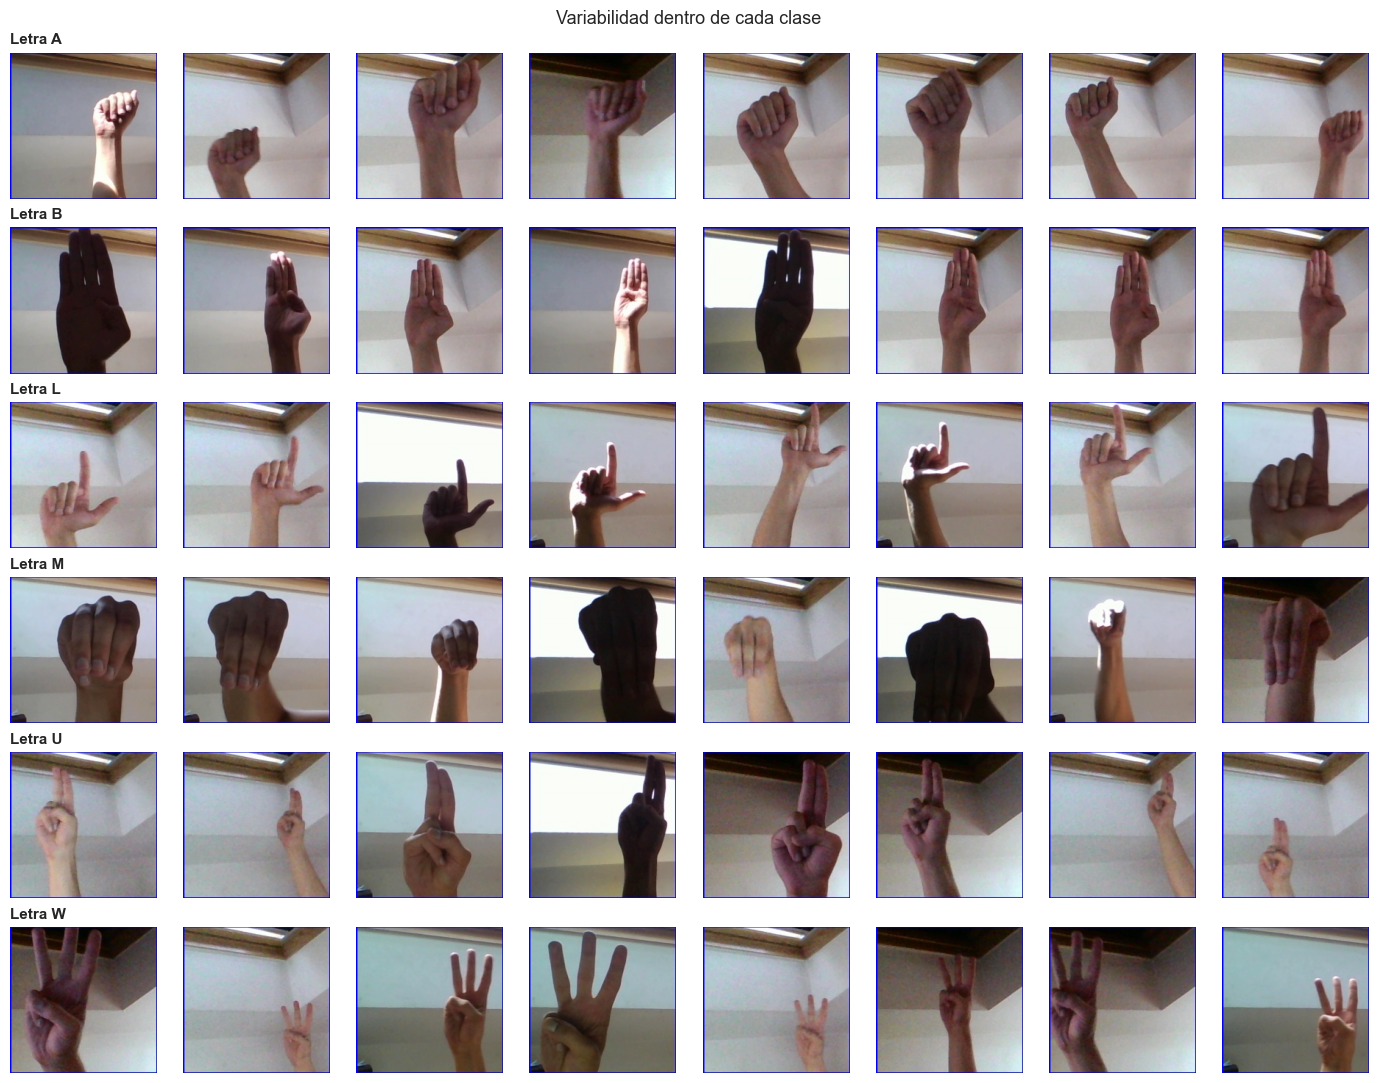

In [6]:
LETRAS_EJEMPLO = ["A", "B", "L", "M", "U", "W"]
N_EJEMPLOS = 8

rng_ej = random.Random(SEMILLA)
fig, axes = plt.subplots(len(LETRAS_EJEMPLO), N_EJEMPLOS, figsize=(14, 11))
for i, clase in enumerate(LETRAS_EJEMPLO):
    rutas = sorted((DIR_TRAIN / clase).glob("*.jpg"))
    elegidas = rng_ej.sample(rutas, N_EJEMPLOS)
    for j, ruta in enumerate(elegidas):
        axes[i, j].imshow(Image.open(ruta))
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(f"Letra {clase}", loc="left",
                                 fontsize=11, fontweight="bold")
fig.suptitle("Variabilidad dentro de cada clase", fontsize=13)
plt.tight_layout()
plt.show()

La variabilidad dentro de una clase viene sobre todo de la iluminacion y de la
distancia de la mano a la camara. La pose de los dedos se mantiene bastante
estable porque cada clase se grabo en una sola sesion continua. Eso adelanta un
problema que se confirma en la seccion 2.6, las imagenes de una misma letra no
son independientes entre si.

## 2.1. Resolucion y formato

Se verifica sobre una muestra amplia que todas las imagenes compartan tamano,
modo de color y formato.

In [7]:
rng_fmt = random.Random(SEMILLA)
props = []
for clase in CLASES:
    rutas = sorted((DIR_TRAIN / clase).glob("*.jpg"))
    for ruta in rng_fmt.sample(rutas, 20):
        with Image.open(ruta) as im:
            props.append({"tamano": str(im.size), "modo": im.mode, "formato": im.format})

df_props = pd.DataFrame(props)
print(f"imagenes revisadas: {len(df_props):,}")
for col in df_props.columns:
    conteo = df_props[col].value_counts()
    print(f"{col}: {dict(conteo)}")

imagenes revisadas: 580
tamano: {'(200, 200)': np.int64(580)}
modo: {'RGB': np.int64(580)}
formato: {'JPEG': np.int64(580)}


## 2.2. Distribucion de clases

El conteo cubre las 87,000 imagenes del conjunto de entrenamiento, no la
submuestra.

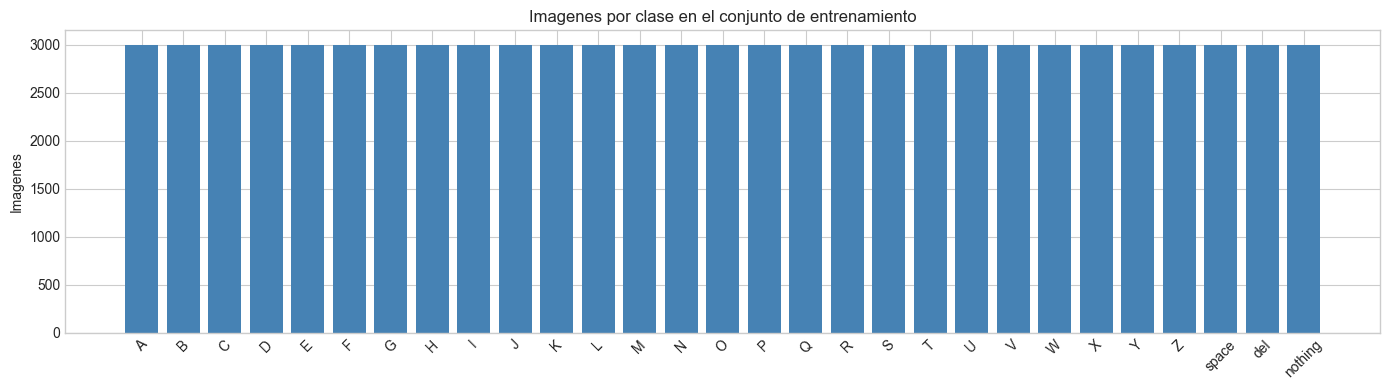

minimo 3,000   maximo 3,000   total 87,000
desviacion entre clases: 0.00
dataset balanceado


In [8]:
conteo = inventario.set_index("clase")["imagenes"].reindex(CLASES)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(conteo.index, conteo.values, color="steelblue")
ax.set(title="Imagenes por clase en el conjunto de entrenamiento", ylabel="Imagenes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"minimo {conteo.min():,}   maximo {conteo.max():,}   total {conteo.sum():,}")
print(f"desviacion entre clases: {conteo.std():.2f}")
print("dataset balanceado" if conteo.std() == 0 else "dataset desbalanceado")

## 2.3. Peso de los archivos por clase

El tamano de un JPEG crece con la cantidad de detalle de la imagen, asi que
sirve como medida indirecta de complejidad visual sin mirar los pixeles.

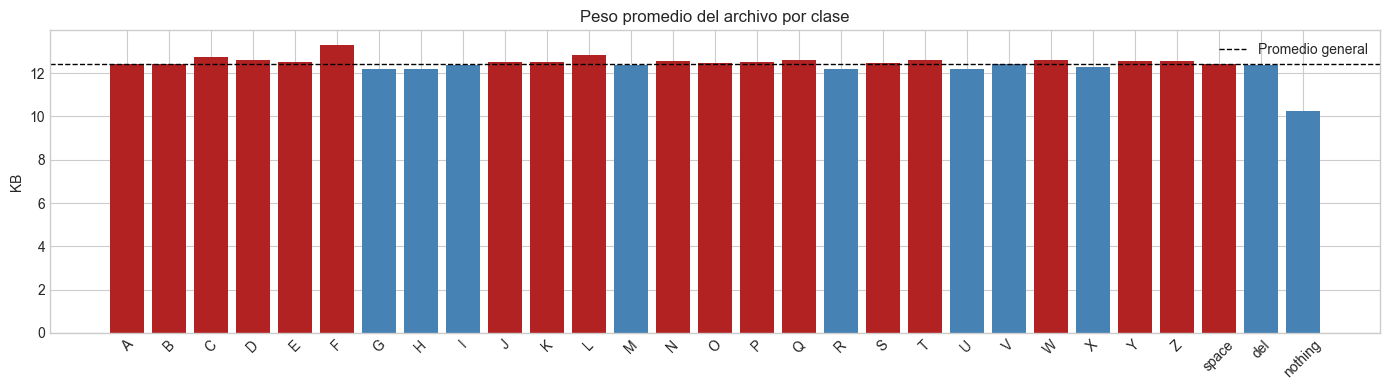

,KB
clase,
nothing,10.3
U,12.2
R,12.2
F,13.3
L,12.8
C,12.8


In [9]:
peso = inventario.set_index("clase")["kb_promedio"].reindex(CLASES)

fig, ax = plt.subplots(figsize=(14, 4))
colores = ["firebrick" if v > peso.mean() else "steelblue" for v in peso]
ax.bar(peso.index, peso.values, color=colores)
ax.axhline(peso.mean(), color="black", ls="--", lw=1, label="Promedio general")
ax.set(title="Peso promedio del archivo por clase", ylabel="KB")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

extremos = pd.concat([peso.nsmallest(3), peso.nlargest(3)]).to_frame("KB")
display(extremos.style.format({"KB": "{:.1f}"}))

## 2.4. Submuestra de trabajo

Se fija la submuestra de 600 imagenes por clase que usan este notebook y los
siguientes. El muestreo es aleatorio sobre las 3,000 de cada clase y no los
primeros 600, porque las imagenes consecutivas son cuadros contiguos del mismo
video, cosa que se comprueba en la seccion 2.6.

El enunciado sugiere entre 500 y 800 por clase. Con 600 quedan 17,400 imagenes,
suficientes para entrenar varias arquitecturas en tiempo razonable y sin perder
la cobertura de la variabilidad de cada clase.

In [10]:
rng_sub = random.Random(SEMILLA)
submuestra = {}
for clase in CLASES:
    rutas = sorted((DIR_TRAIN / clase).glob("*.jpg"))
    submuestra[clase] = rng_sub.sample(rutas, SUBMUESTRA)

total_sub = sum(len(v) for v in submuestra.values())
print(f"submuestra fijada: {total_sub:,} imagenes en {len(submuestra)} clases")

submuestra fijada: 17,400 imagenes en 29 clases


## 2.5. Color e iluminacion

Se revisa si las clases difieren en brillo o contraste. Una diferencia
sistematica seria una pista que el modelo podria aprovechar en lugar de
aprender la forma de la mano.

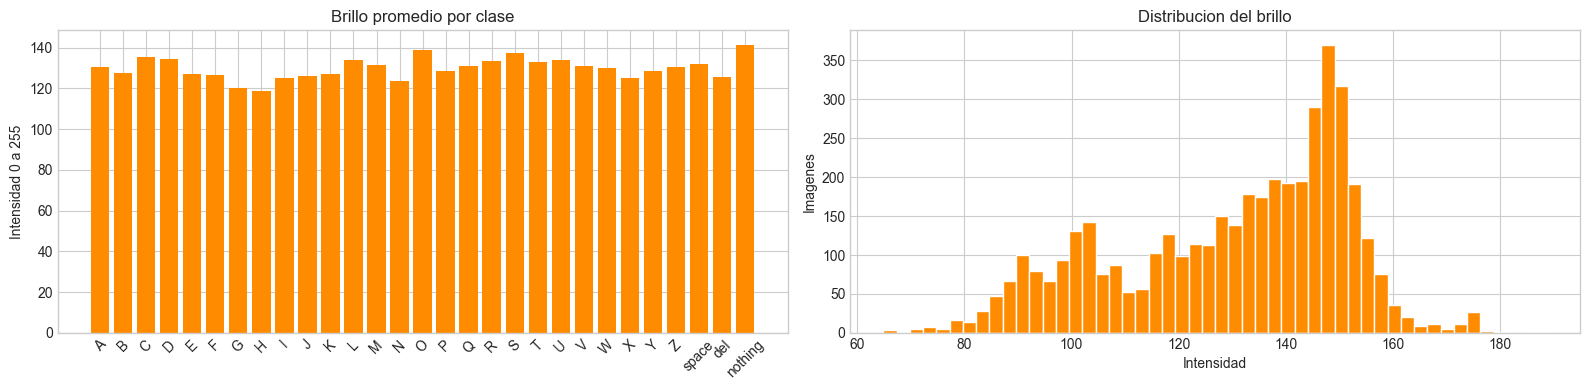

,brillo,contraste,rojo,verde,azul
count,4350.0,4350.0,4350.0,4350.0,4350.0
mean,129.9,58.0,132.0,126.8,130.8
std,21.6,14.9,20.2,22.0,23.1
min,64.9,30.4,76.2,61.3,56.7
25%,114.9,46.6,114.9,112.1,115.3
50%,135.3,54.8,135.4,132.6,136.8
75%,147.3,63.0,148.2,144.0,149.7
max,188.7,98.2,191.2,188.3,186.5


rango del brillo promedio entre clases: 118.8 a 141.4


In [11]:
N_ANALISIS = 150

filas_lum = []
for clase in CLASES:
    for ruta in submuestra[clase][:N_ANALISIS]:
        arr = np.asarray(Image.open(ruta), dtype=np.float32)
        filas_lum.append({
            "clase": clase,
            "brillo": arr.mean(),
            "contraste": arr.std(),
            "rojo": arr[:, :, 0].mean(),
            "verde": arr[:, :, 1].mean(),
            "azul": arr[:, :, 2].mean(),
        })

df_lum = pd.DataFrame(filas_lum)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
orden = df_lum.groupby("clase")["brillo"].mean().reindex(CLASES)
axes[0].bar(orden.index, orden.values, color="darkorange")
axes[0].set(title="Brillo promedio por clase", ylabel="Intensidad 0 a 255")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(df_lum["brillo"], bins=50, color="darkorange", edgecolor="white")
axes[1].set(title="Distribucion del brillo", xlabel="Intensidad", ylabel="Imagenes")
plt.tight_layout()
plt.show()

display(df_lum[["brillo", "contraste", "rojo", "verde", "azul"]].describe().round(1))
print(f"rango del brillo promedio entre clases: "
      f"{orden.min():.1f} a {orden.max():.1f}")

## 2.6. Letras visualmente similares

Se calcula la imagen promedio de cada clase, se pasa a escala de grises
reducida y se mide la distancia euclidiana entre centroides. Dos clases
cercanas comparten silueta y son candidatas a confundirse.

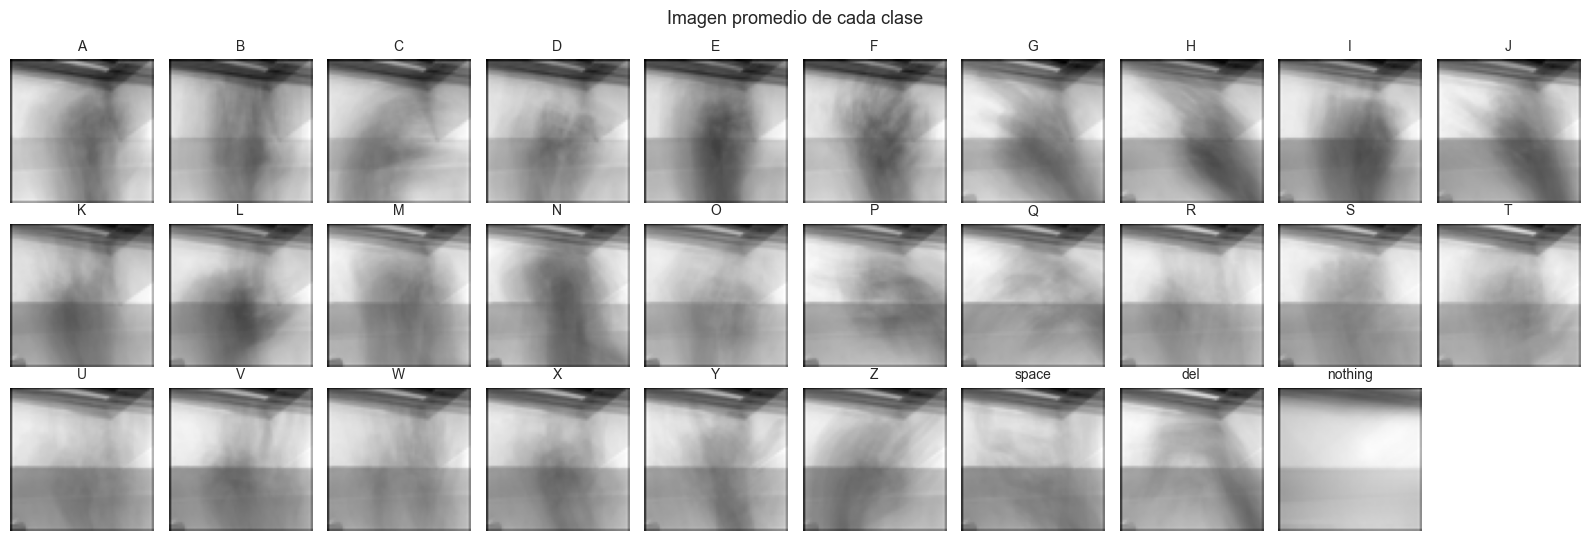

In [12]:
LADO = 64

centroides = {}
for clase in CLASES:
    acumulado = np.zeros((LADO, LADO), dtype=np.float64)
    rutas = submuestra[clase][:N_ANALISIS]
    for ruta in rutas:
        im = Image.open(ruta).convert("L").resize((LADO, LADO))
        acumulado += np.asarray(im, dtype=np.float64)
    centroides[clase] = acumulado / len(rutas)

fig, axes = plt.subplots(3, 10, figsize=(16, 5.5))
for ax, clase in zip(axes.ravel(), CLASES):
    ax.imshow(centroides[clase], cmap="gray")
    ax.set_title(clase, fontsize=10)
    ax.axis("off")
for ax in axes.ravel()[len(CLASES):]:
    ax.axis("off")
fig.suptitle("Imagen promedio de cada clase", fontsize=13)
plt.tight_layout()
plt.show()

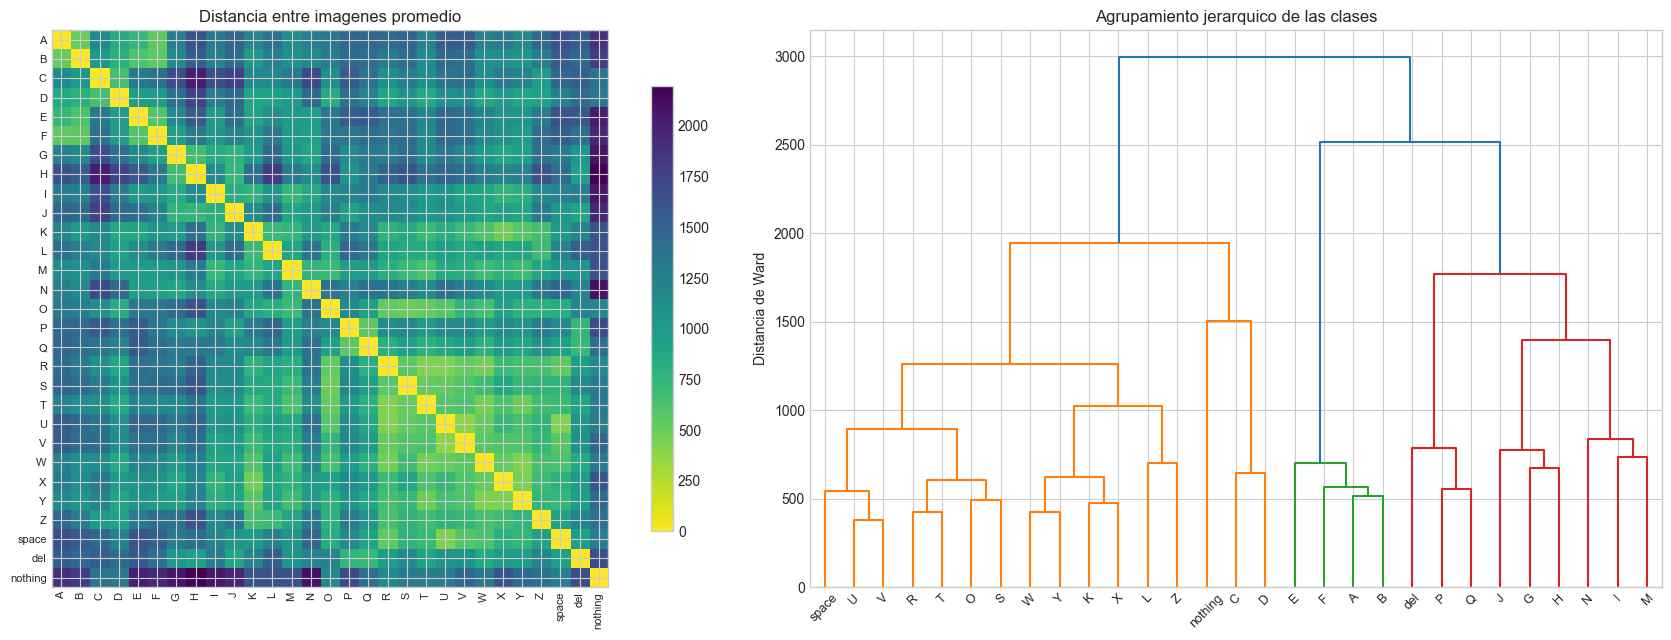

In [13]:
matriz = np.stack([centroides[c].ravel() for c in CLASES])
distancias = pd.DataFrame(squareform(pdist(matriz, metric="euclidean")),
                          index=CLASES, columns=CLASES)

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
im = axes[0].imshow(distancias, cmap="viridis_r")
axes[0].set_xticks(range(len(CLASES)))
axes[0].set_xticklabels(CLASES, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(CLASES)))
axes[0].set_yticklabels(CLASES, fontsize=8)
axes[0].set_title("Distancia entre imagenes promedio")
fig.colorbar(im, ax=axes[0], shrink=0.8)

enlaces = linkage(matriz, method="ward")
dendrogram(enlaces, labels=CLASES, ax=axes[1], leaf_font_size=9)
axes[1].set(title="Agrupamiento jerarquico de las clases", ylabel="Distancia de Ward")
plt.tight_layout()
plt.show()

In [14]:
pares = [(a, b, distancias.loc[a, b])
         for i, a in enumerate(CLASES) for b in CLASES[i + 1:]]
tabla_pares = pd.DataFrame(pares, columns=["Clase A", "Clase B", "Distancia"])

print("LOS 12 PARES MAS PARECIDOS")
display(tabla_pares.nsmallest(12, "Distancia").reset_index(drop=True)
        .style.format({"Distancia": "{:.1f}"}))

print("GRUPOS QUE MENCIONA EL ENUNCIADO")
for grupo in [["M", "N", "S"], ["U", "V", "R"]]:
    for i, a in enumerate(grupo):
        for b in grupo[i + 1:]:
            d = distancias.loc[a, b]
            pct = (tabla_pares["Distancia"] < d).mean() * 100
            print(f"  {a} y {b}: distancia {d:6.1f}   percentil {pct:5.1f}")

LOS 12 PARES MAS PARECIDOS


,Clase A,Clase B,Distancia
0,U,V,381.6
1,R,T,425.7
2,U,space,425.9
3,R,U,425.9
4,W,Y,426.1
5,X,Y,439.4
6,R,W,463.4
7,T,W,467.4
8,K,X,477.4
9,O,S,491.2


GRUPOS QUE MENCIONA EL ENUNCIADO
  M y N: distancia  752.9   percentil  17.5
  M y S: distancia  706.3   percentil  13.5
  N y S: distancia 1252.7   percentil  65.3
  U y V: distancia  381.6   percentil   0.0
  U y R: distancia  425.9   percentil   0.7
  V y R: distancia  527.9   percentil   3.7


El resultado matiza lo que plantea el enunciado. El grupo U, V y R queda
confirmado con claridad. U y V es el par mas parecido de las 406 combinaciones
posibles, en el percentil 0, y R con U esta en el percentil 0.7. Los tres son
senas de dedos extendidos hacia arriba que solo se diferencian por la
separacion o el cruce entre ellos, un detalle que casi desaparece al reducir la
resolucion.

El grupo M, N y S resulta menos homogeneo de lo esperado. M con S esta en el
percentil 13.5 y M con N en el 17.5, o sea que si son cercanos, pero N con S
cae en el percentil 65.3, es decir en la mitad mas alejada de todos los pares.
La razon es que las tres son variantes de puno cerrado y lo que las distingue
es la posicion del pulgar, que la imagen promedio difumina.

Ademas aparecen vecindades que el enunciado no menciona y que conviene vigilar.
R con T, W con Y, X con Y y K con X estan entre los ocho pares mas cercanos, y
casi todos pertenecen a la misma familia de dedos extendidos. Tambien resalta
que U aparezca cerca de la clase `space`, lo cual sugiere que esa clase no es
un fondo vacio sino una sena con la mano presente.